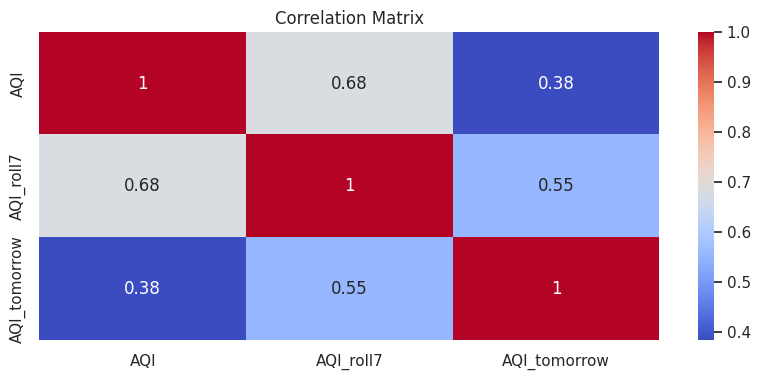


================ CLEAN LINEAR MODEL ================

TRAIN:
RMSE: 2.817230708570716
R2  : 0.3261510969554422

TEST:
RMSE: 2.5878538233483543
R2  : 0.27345113204707405

COEFFICIENTS:
        Feature  Coefficient
0     AQI_roll7     0.635849
11     Month_12     0.254574
10     Month_11     0.221526
15  DayOfWeek_4     0.155816
16  DayOfWeek_5     0.107461
14  DayOfWeek_3     0.075605
13  DayOfWeek_2     0.042071
17  DayOfWeek_6     0.004168
12  DayOfWeek_1    -0.011690
1       Month_2    -0.215033
9      Month_10    -0.371853
8       Month_9    -0.442260
2       Month_3    -0.883581
7       Month_8    -0.955923
3       Month_4    -1.166293
4       Month_5    -1.328138
5       Month_6    -1.370057
6       Month_7    -1.375671

Intercept: 2.4295156037616614


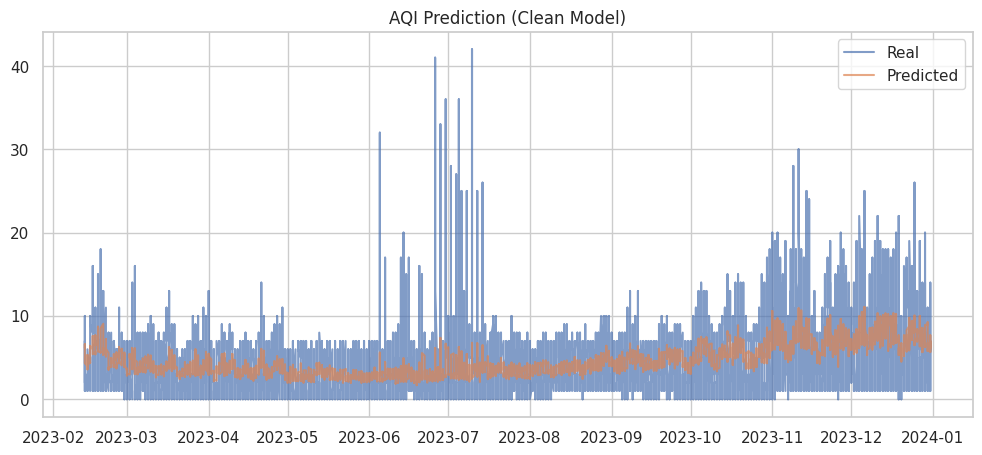

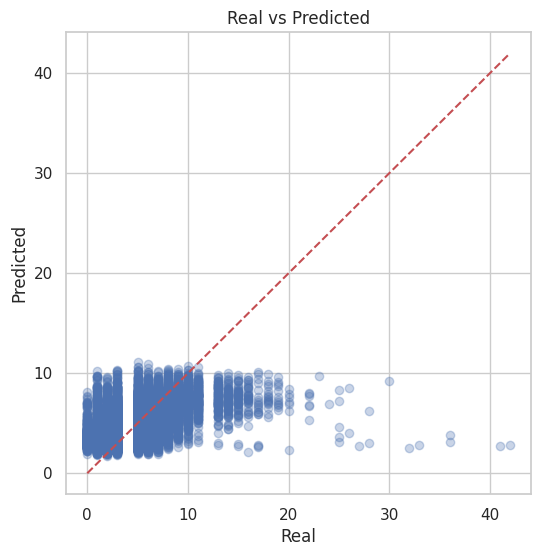

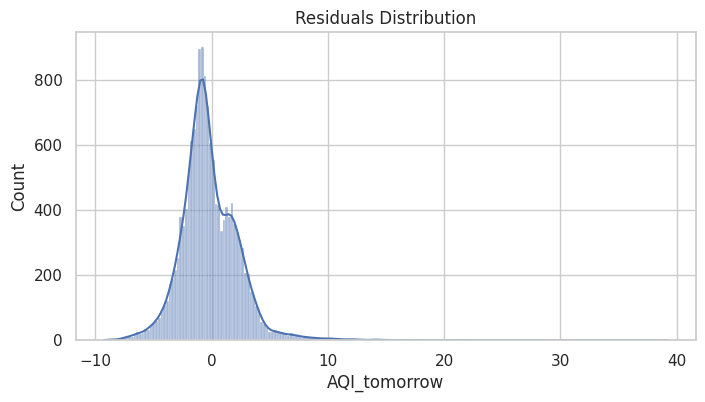


================ INTERPRETACIÓN DEL MODELO ================

 Ecuación del modelo:
AQI_tomorrow = 2.430
 + (0.636 * AQI_roll7)
 + (-0.215 * Month_2)
 + (-0.884 * Month_3)
 + (-1.166 * Month_4)
 + (-1.328 * Month_5)
 + (-1.370 * Month_6)
 + (-1.376 * Month_7)
 + (-0.956 * Month_8)
 + (-0.442 * Month_9)
 + (-0.372 * Month_10)
 + (0.222 * Month_11)
 + (0.255 * Month_12)
 + (-0.012 * DayOfWeek_1)
 + (0.042 * DayOfWeek_2)
 + (0.076 * DayOfWeek_3)
 + (0.156 * DayOfWeek_4)
 + (0.107 * DayOfWeek_5)
 + (0.004 * DayOfWeek_6)

 Qué significa el modelo:
- El AQI de los últimos 7 días (AQI_roll7) es el factor más importante.
- Los meses del año influyen en la contaminación (estacionalidad).
- El día de la semana tiene poco impacto en comparación.

 Conclusión:
- El modelo explica aproximadamente 27.35% del AQI
- El error promedio es de 2.59 unidades de AQI


In [34]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

df_2020 = pd.read_csv("co_2020.csv")
df_2021 = pd.read_csv("co_2021.csv")
df_2022 = pd.read_csv("co_2022.csv")
df_2023 = pd.read_csv("co_2023.csv")

data = pd.concat([df_2020, df_2021, df_2022, df_2023], ignore_index=True)

#limpieza
data["Date"] = pd.to_datetime(data["Date"])
data["AQI"] = pd.to_numeric(data["Daily AQI Value"], errors="coerce")

data = data.sort_values("Date").reset_index(drop=True)

#defino el target aqui+1 el mañana
data["AQI_tomorrow"] = data["AQI"].shift(-1)

#Datos no redundantes
data["AQI_roll7"] = data["AQI"].rolling(7).mean()

data["Month"] = data["Date"].dt.month
data["DayOfWeek"] = data["Date"].dt.dayofweek

data = data.dropna().reset_index(drop=True)

#eda
plt.figure(figsize=(10,4))
sns.heatmap(data[["AQI", "AQI_roll7", "AQI_tomorrow"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

cutoff = data["Date"].quantile(0.8)

train = data[data["Date"] < cutoff].copy()
test  = data[data["Date"] >= cutoff].copy()

y_train = train["AQI_tomorrow"]
y_test  = test["AQI_tomorrow"]

#onehot encoding
train = pd.get_dummies(train, columns=["Month", "DayOfWeek"], drop_first=True)
test  = pd.get_dummies(test, columns=["Month", "DayOfWeek"], drop_first=True)

test = test.reindex(columns=train.columns, fill_value=0)


features = ["AQI_roll7"]

month_features = [c for c in train.columns if "Month_" in c]
dow_features   = [c for c in train.columns if "DayOfWeek_" in c]

features = features + month_features + dow_features

X_train = train[features]
X_test  = test[features]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

#metricas
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))

r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test, y_pred_test)

print("\n================ CLEAN LINEAR MODEL ================\n")

print("TRAIN:")
print("RMSE:", rmse_train)
print("R2  :", r2_train)

print("\nTEST:")
print("RMSE:", rmse_test)
print("R2  :", r2_test)


coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

print("\nCOEFFICIENTS:")
print(coef_df)

print("\nIntercept:", model.intercept_)



plt.figure(figsize=(12,5))
plt.plot(test["Date"], y_test.values, label="Real", alpha=0.7)
plt.plot(test["Date"], y_pred_test, label="Predicted", alpha=0.7)
plt.legend()
plt.title("AQI Prediction (Clean Model)")
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--")
plt.xlabel("Real")
plt.ylabel("Predicted")
plt.title("Real vs Predicted")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(y_test - y_pred_test, kde=True)
plt.title("Residuals Distribution")
plt.show()


print("\n================ INTERPRETACIÓN DEL MODELO ================\n")
print(" Ecuación del modelo:")
print(f"AQI_tomorrow = {model.intercept_:.3f}")

for f, c in zip(features, model.coef_):
    print(f" + ({c:.3f} * {f})")

print("\n Qué significa el modelo:")

print("- El AQI de los últimos 7 días (AQI_roll7) es el factor más importante.")
print("- Los meses del año influyen en la contaminación (estacionalidad).")
print("- El día de la semana tiene poco impacto en comparación.")

print("\n Conclusión:")
print(f"- El modelo explica aproximadamente {r2_test:.2%} del AQI")
print(f"- El error promedio es de {rmse_test:.2f} unidades de AQI")